# Mes -> PyVista Quick Viewer (Standalone)

두 개의 `.mes` 케이스를 독립적으로 처리해 다음 산출물을 생성합니다.
- standard mesh h5
- vtu
- clip vtu
- pyvista 스크린샷

`OnLoadTorque`는 `run_real_mes_pipeline.run_pipeline` 경로를,
`OnLoadLoss`는 loss txt fallback 경로를 사용합니다.

In [20]:
from pathlib import Path
import importlib
import json
import sys

import numpy as np
import h5py
import pyvista as pv
from IPython.display import Image, display

sys.path.insert(0, r"D:/KangDH/Emlab_emach/Class/pyMotorGeo")
sys.path.insert(0, r"D:/KangDH/Emlab_emach")

import run_real_mes_pipeline as _real_pipeline
importlib.reload(_real_pipeline)
run_pipeline = _real_pipeline.run_pipeline

from motorcad_h5_adapter import MotorH5Adapter
from tools.motorCAD.pyMCAD.fea_workflow import process_fea_result_from_mes
from tools.motorCAD.pyMCAD.loss import get_element_loss_fields_from_file

import ansys.motorcad.core as pymotorcad

In [21]:
def _materialize_from_standard_h5(standard_h5: Path, out_dir: Path, scalar_name: str | None = None):
    out_dir.mkdir(parents=True, exist_ok=True)
    vtu_path = out_dir / "standard_mesh_sample.vtu"
    clip_vtu_path = out_dir / "standard_mesh_sample_clip.vtu"
    png_path = out_dir / "standard_mesh_clip.png"

    adp = MotorH5Adapter()
    adp.load_h5(standard_h5)
    adp.to_unstructured_grid(points_key="mesh/points", cells_key="mesh/connectivity")

    if scalar_name and scalar_name in adp.datasets:
        adp.add_cell_data(scalar_name.split("/")[-1], adp.datasets[scalar_name])

    adp.save_vtu(vtu_path)
    clipped = adp.clip(normal="x", origin=(0.0, 0.0, 0.0), invert=False)
    clipped.save(str(clip_vtu_path))

    scalar_key = scalar_name.split("/")[-1] if scalar_name else None
    plotter = pv.Plotter(off_screen=True)
    if scalar_key and scalar_key in clipped.cell_data:
        plotter.add_mesh(clipped, scalars=scalar_key, show_edges=True)
    else:
        plotter.add_mesh(clipped, color="lightgray", show_edges=True)
    plotter.show(screenshot=str(png_path), auto_close=True)

    return {
        "standard_h5": str(standard_h5),
        "vtu_path": str(vtu_path),
        "clip_vtu_path": str(clip_vtu_path),
        "plot_png": str(png_path),
        "clip_points": int(clipped.n_points),
        "clip_cells": int(clipped.n_cells),
    }


def _run_loss_fallback(mot_path: Path, mes_path: Path, out_dir: Path) -> dict:
    out_dir.mkdir(parents=True, exist_ok=True)
    mc = pymotorcad.MotorCAD(open_new_instance=True)
    mc.set_variable("MessageDisplayState", 2)
    mc.load_from_file(str(mot_path))

    result = process_fea_result_from_mes(
        mc,
        mes_path=str(mes_path),
        plot_mode="none",
        out_dir=str(out_dir),
        first_step=1,
        final_step=45,
        export_magnetic_h5=False,
        include_magnetic_export=False,
    )

    if result.loss_export_path is None:
        raise RuntimeError("loss_export_path is None for loss fallback")

    fields = get_element_loss_fields_from_file(
        result.loss_export_path,
        unit="W/kg",
        clean_up=False,
    )
    if not fields:
        raise RuntimeError("No loss fields parsed from loss_export_path")

    field_name = "Pt" if "Pt" in fields else next(iter(fields.keys()))
    field = fields[field_name]
    mesh = field.mesh

    node_ids = sorted(mesh.node_xy.keys())
    node_index = {nid: i for i, nid in enumerate(node_ids)}
    points = np.array(
        [[mesh.node_xy[nid][0], mesh.node_xy[nid][1], 0.0] for nid in node_ids],
        dtype=np.float64,
    )

    elements = list(mesh.elements)
    connectivity = np.array(
        [[node_index[e.node_1], node_index[e.node_2], node_index[e.node_3]] for e in elements],
        dtype=np.int64,
    )
    values = np.array(
        [field.values_by_tri.get(int(e.tri_index), np.nan) for e in elements],
        dtype=np.float32,
    )

    standard_h5 = out_dir / "standard_mesh_sample.h5"
    scalar_ds = f"fields/{field_name}_cell"
    with h5py.File(standard_h5, "w") as f:
        f.create_dataset("mesh/points", data=points)
        f.create_dataset("mesh/connectivity", data=connectivity)
        f.create_dataset(scalar_ds, data=values)

    mat = _materialize_from_standard_h5(standard_h5, out_dir, scalar_name=scalar_ds)

    return {
        "mode": "loss_fallback",
        "mot_path": str(mot_path),
        "mes_path": str(mes_path),
        "output_dir": str(out_dir),
        "loss_export_path": str(result.loss_export_path),
        "field_name": field_name,
        **mat,
        "export_error": None,
    }


def _default_convert_dir(mot_path: str | Path, convert_dir_name: str = "converted_mesh") -> Path:
    return Path(mot_path).parent / convert_dir_name


def run_case(
    mot_path: str | Path,
    mes_path: str | Path,
    out_dir: str | Path | None = None,
    convert_dir_name: str = "converted_mesh",
) -> dict:
    mot = Path(mot_path)
    mes = Path(mes_path)
    out = Path(out_dir) if out_dir else _default_convert_dir(mot, convert_dir_name)

    try:
        result = run_pipeline(
            mot_path=mot,
            mes_path=mes,
            out_dir=out,
            convert_dir_name=convert_dir_name,
        )
        result["mode"] = "mag_pipeline"
    except FileNotFoundError as exc:
        print("mag pipeline fallback:", exc)
        result = _run_loss_fallback(mot_path=mot, mes_path=mes, out_dir=out)

    result_json = Path(result["output_dir"]) / "run_result.json"
    result_json.write_text(
        json.dumps(result, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    print(json.dumps(result, indent=2, ensure_ascii=False))
    return result


def show_result(result: dict):
    print("mode:", result.get("mode"))
    print("output_dir:", result.get("output_dir"))
    print("clip points/cells:", result.get("clip_points"), result.get("clip_cells"))
    png = result.get("plot_png")
    if png and Path(png).exists():
        display(Image(filename=png))

In [18]:
case1 = {
    "name": "c688_onloadloss",
    "mot": r"E:/KDH/KJS/C688/c688_i5Base.mot",
    "mes": r"E:/KDH/KJS/C688/c688_i5Base/FEResultsData/OnLoadLoss_result_1.mes",
}

case2 = {
    "name": "vtype_design0051_onloadtorque",
    "mot": r"G:/KangDH/LabProj2023v3/8p48sV/230819_8P48S_Vtype/DOE/8P48S_Vtype_Design0051/8P48S_Vtype_Design0051.mot",
    "mes": r"G:/KangDH/LabProj2023v3/8p48sV/230819_8P48S_Vtype/DOE/8P48S_Vtype_Design0051/8P48S_Vtype_Design0051/FEResultsData/OnLoadTorque_result_1.mes",
}

for c in [case1, case2]:
    out_dir = _default_convert_dir(c["mot"])
    print(
        c["name"],
        "mes exists:", Path(c["mes"]).exists(),
        "mot exists:", Path(c["mot"]).exists(),
        "out_dir:", out_dir,
    )

c688_onloadloss mes exists: True mot exists: True out_dir: E:\KDH\KJS\C688\converted_mesh
vtype_design0051_onloadtorque mes exists: True mot exists: True out_dir: G:\KangDH\LabProj2023v3\8p48sV\230819_8P48S_Vtype\DOE\8P48S_Vtype_Design0051\converted_mesh


Widget(value='<iframe src="http://localhost:59971/index.html?ui=P_0x20f8d5dc490_3&reconnect=auto" class="pyvis…

{
  "mot_path": "E:\\KDH\\KJS\\C688\\c688_i5Base.mot",
  "mes_path": "E:\\KDH\\KJS\\C688\\c688_i5Base\\FEResultsData\\OnLoadLoss_result_1.mes",
  "output_dir": "E:\\KDH\\KJS\\C688\\converted_mesh",
  "source_h5": null,
  "loss_txt_path": "E:\\KDH\\KJS\\C688\\converted_mesh\\LossElement_OnLoadLoss_result_1.txt",
  "standard_h5": "E:\\KDH\\KJS\\C688\\converted_mesh\\standard_mesh_sample.h5",
  "vtu_path": "E:\\KDH\\KJS\\C688\\converted_mesh\\standard_mesh_sample.vtu",
  "clip_vtu_path": "E:\\KDH\\KJS\\C688\\converted_mesh\\standard_mesh_sample_clip.vtu",
  "clip_points": 1151,
  "clip_cells": 1872,
  "plot_png": "E:\\KDH\\KJS\\C688\\converted_mesh\\standard_mesh_clip.png",
  "export_error": null,
  "mode": "mag_pipeline"
}
mode: mag_pipeline
output_dir: E:\KDH\KJS\C688\converted_mesh
clip points/cells: 1151 1872


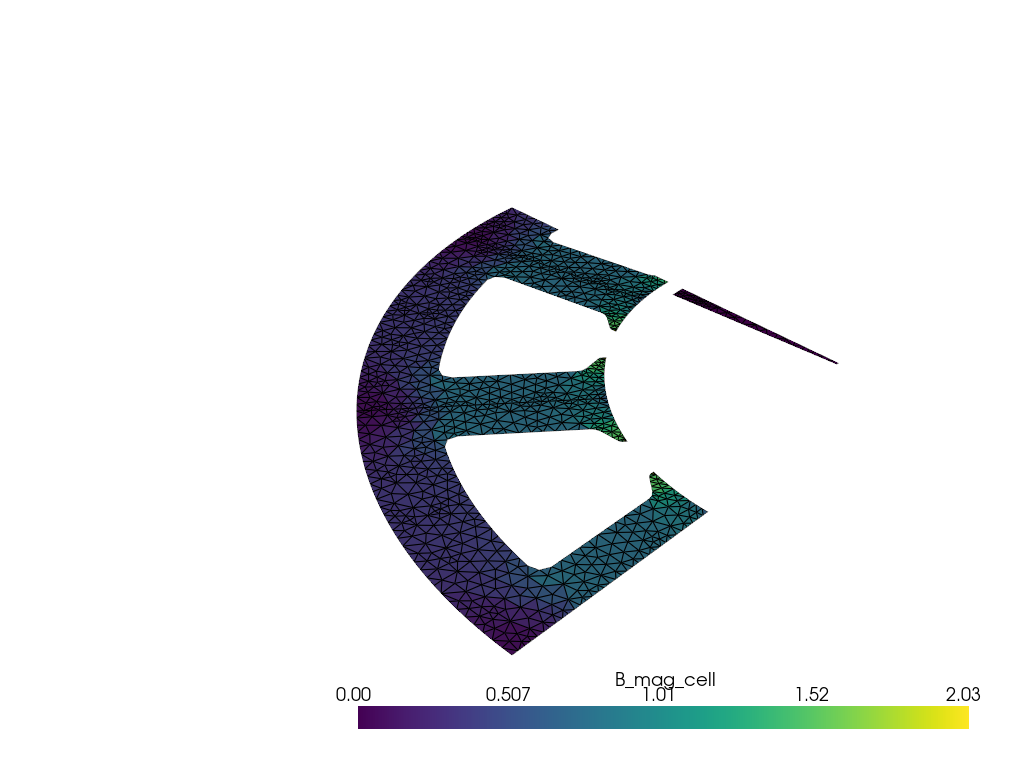

In [22]:
res_case1 = run_case(case1["mot"], case1["mes"])
show_result(res_case1)

Widget(value='<iframe src="http://localhost:59971/index.html?ui=P_0x20f88816380_2&reconnect=auto" class="pyvis…

{
  "mot_path": "G:\\KangDH\\LabProj2023v3\\8p48sV\\230819_8P48S_Vtype\\DOE\\8P48S_Vtype_Design0051\\8P48S_Vtype_Design0051.mot",
  "mes_path": "G:\\KangDH\\LabProj2023v3\\8p48sV\\230819_8P48S_Vtype\\DOE\\8P48S_Vtype_Design0051\\8P48S_Vtype_Design0051\\FEResultsData\\OnLoadTorque_result_1.mes",
  "source_h5": "D:\\KangDH\\Emlab_emach\\Class\\pyMotorGeo\\_tmp_case2_onloadtorque\\Mag_OnLoadTorque_result_1.h5",
  "standard_h5": "D:\\KangDH\\Emlab_emach\\Class\\pyMotorGeo\\_tmp_case2_onloadtorque\\standard_mesh_sample.h5",
  "vtu_path": "D:\\KangDH\\Emlab_emach\\Class\\pyMotorGeo\\_tmp_case2_onloadtorque\\standard_mesh_sample.vtu",
  "clip_vtu_path": "D:\\KangDH\\Emlab_emach\\Class\\pyMotorGeo\\_tmp_case2_onloadtorque\\standard_mesh_sample_clip.vtu",
  "clip_points": 7097,
  "clip_cells": 13944,
  "plot_png": "D:\\KangDH\\Emlab_emach\\Class\\pyMotorGeo\\_tmp_case2_onloadtorque\\standard_mesh_clip.png",
  "export_error": null,
  "mode": "mag_pipeline"
}
mode: mag_pipeline
clip points/cells:

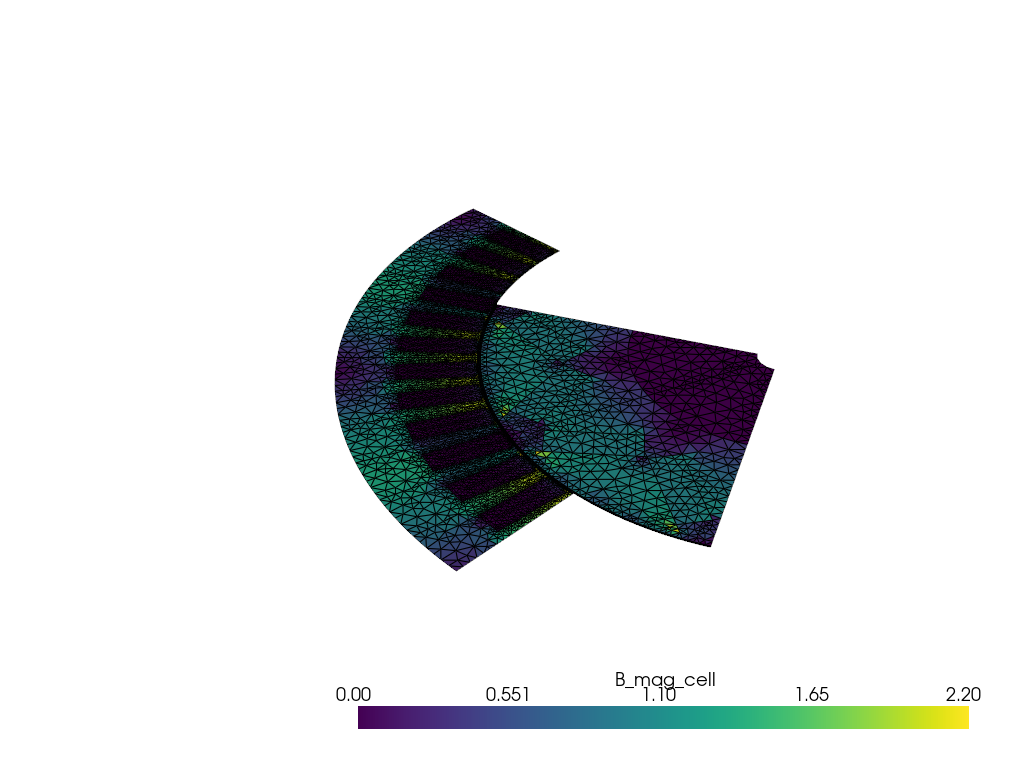

In [ ]:
res_case2 = run_case(case2["mot"], case2["mes"])
show_result(res_case2)

In [14]:
summary = [
    {
        "case": case1["name"],
        "mode": res_case1.get("mode"),
        "clip_points": res_case1.get("clip_points"),
        "clip_cells": res_case1.get("clip_cells"),
        "clip_vtu": res_case1.get("clip_vtu_path"),
    },
    {
        "case": case2["name"],
        "mode": res_case2.get("mode"),
        "clip_points": res_case2.get("clip_points"),
        "clip_cells": res_case2.get("clip_cells"),
        "clip_vtu": res_case2.get("clip_vtu_path"),
    },
]
print(json.dumps(summary, indent=2, ensure_ascii=False))

[
  {
    "case": "c688_onloadloss",
    "mode": "loss_fallback",
    "clip_points": 1151,
    "clip_cells": 1872,
    "clip_vtu": "D:\\KangDH\\Emlab_emach\\Class\\pyMotorGeo\\_tmp_case1_onloadloss\\standard_mesh_sample_clip.vtu"
  },
  {
    "case": "vtype_design0051_onloadtorque",
    "mode": "mag_pipeline",
    "clip_points": 7097,
    "clip_cells": 13944,
    "clip_vtu": "D:\\KangDH\\Emlab_emach\\Class\\pyMotorGeo\\_tmp_case2_onloadtorque\\standard_mesh_sample_clip.vtu"
  }
]
